In [2]:
import os
import time
import numpy as np
import polars as pl
import optuna

# Forzamos CPU antes de importar TensorFlow para que el notebook sea reproducible desde un kernel limpio
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print('TensorFlow configurado en CPU antes de iniciar el entrenamiento del MLP.')

TensorFlow configurado en CPU antes de iniciar el entrenamiento del MLP.


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [3]:
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ==========================================
# BLOQUE 0: PARCHE PARA FORZAR USO DE CPU
# ==========================================
# sto DEBE ir antes de importar TensorFlow
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # Oculta la gráfica a TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suprime warnings molestos de C++

print("✅ GPU desactivada por compatibilidad. Entrenando en CPU pura.")

# ==========================================
# BLOQUE 1: PREPARACIÓN GLOBAL
# ==========================================
# 1. Forzamos la conversión a matriz plana
X_train_np = np.array(X_full_train_np)
y_train_np = np.array(y_full_train)

# 2. Convertimos las etiquetas -1/1 a 0/1 (Vital para ciberseguridad / Sigmoide)
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)

# 3. El escalado se hará dentro de cada fold para evitar data leakage
print("Preparando TensorFlow con escalado por fold...")

# ==========================================
# BLOQUE 2: FUNCIÓN OBJECTIVE (EL CORAZÓN)
# ==========================================
def objective(trial):
    warnings.filterwarnings("ignore")
    
    # Limpiar memoria de RAM entre cada intento
    tf.keras.backend.clear_session()
    
    # 2.1 Espacio de búsqueda de arquitectura
    n_layers = trial.suggest_int("n_layers", 1, 3)
    
    # Siempre sugerimos el número de neuronas para todas las posibles capas
    n_units_l0 = trial.suggest_int("n_units_l0", 16, 128, step=16)
    n_units_l1 = trial.suggest_int("n_units_l1", 16, 128, step=16)
    n_units_l2 = trial.suggest_int("n_units_l2", 16, 128, step=16)
    
    # 2.2 Configuración CV (2 Folds para ir rápido)
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    f1_scores = []
    latencies = [] 

    # 2.3 Bucle de Entrenamiento y Medición
    for train_idx, val_idx in skf.split(X_train_np, y_train_01):
        X_train_cv_raw, X_val_cv_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_train_cv, y_val_cv = y_train_01[train_idx], y_train_01[val_idx]

        # Escalado ajustado solo con el fold de entrenamiento
        scaler = StandardScaler()
        X_train_cv = scaler.fit_transform(X_train_cv_raw) # Escalamos el fold de entrenamiento
        X_val_cv = scaler.transform(X_val_cv_raw) # Escalamos el fold de validación 

        # --- CONSTRUCCIÓN DE LA RED NEURONAL ---
        model = keras.Sequential()
        model.add(keras.layers.InputLayer(input_shape=(X_train_cv.shape[1],)))
        
        # Capa 1 (Siempre existe)
        model.add(keras.layers.Dense(n_units_l0, activation="relu"))
        # Capa 2 (Opcional)
        if n_layers >= 2:
            model.add(keras.layers.Dense(n_units_l1, activation="relu"))
        # Capa 3 (Opcional)
        if n_layers == 3:
            model.add(keras.layers.Dense(n_units_l2, activation="relu"))
            
        # Capa de salida (1 neurona, Sigmoide para probabilidad)
        model.add(keras.layers.Dense(1, activation="sigmoid"))
        
        # Compilación con Tasa de Aprendizaje por defecto de Adam (0.001)
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        
        # Evita sobreentrenar y ahorra tiempo
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

        # Entrenar (Usa CPU obligatoriamente)
        model.fit(
            X_train_cv, y_train_cv,
            validation_data=(X_val_cv, y_val_cv),
            epochs=30,
            batch_size=2048, # Batch grande para ir rápido
            callbacks=[early_stop],
            verbose=0
        )

        # 1. Predecir y guardar Eficacia (F1)
        y_pred_prob = model.predict(X_val_cv, batch_size=4096, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(np.int8).flatten() # Convertimos a 0/1
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))
        
        # 2. Medir Eficiencia (Latencia) DENTRO DEL FOLD
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        
        # Ya no necesitamos "with tf.device('/CPU:0')" porque TODO está en CPU
        # Warm-up rápido
        _ = model.predict(X_lat[:500], verbose=0)
        
        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat, batch_size=len(X_lat), verbose=0)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)
            
        latencies.append(float(np.mean(rep_lat))) # Guardamos la media de este fold

    # 2.5 El Retorno
    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies)) # Media de todos los folds
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# ==========================================
# BLOQUE 3: EJECUCIÓN DEL ESTUDIO
# ==========================================
study = optuna.create_study(directions=["maximize", "minimize"], study_name="tf_mlp_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con TensorFlow (Entrenamiento y Inferencia en CPU)...")
study.optimize(objective, n_trials=30)

# ==========================================
# BLOQUE 4: EXTRACCIÓN Y PARETO
# ==========================================
pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_layers": t.params["n_layers"],
            "n_units_l0": t.params.get("n_units_l0", 0),
            "n_units_l1": t.params.get("n_units_l1", 0),
            "n_units_l2": t.params.get("n_units_l2", 0),
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("tf_mlp_ton_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'tf_mlp_ton_trials_results_cv.csv'")

[I 2026-05-02 12:00:29,850] A new study created in memory with name: tf_mlp_ids_optimization


✅ GPU desactivada por compatibilidad. Entrenando en CPU pura.
Preparando TensorFlow con escalado por fold...
🚀 Iniciando barrido multiobjetivo con TensorFlow (Entrenamiento y Inferencia en CPU)...


[I 2026-05-02 12:00:50,136] Trial 0 finished with values: [0.9605640966275639, 0.0035978827450890093] and parameters: {'n_layers': 3, 'n_units_l0': 64, 'n_units_l1': 128, 'n_units_l2': 80}.
[I 2026-05-02 12:01:03,419] Trial 1 finished with values: [0.9311975273278217, 0.0035240446095122025] and parameters: {'n_layers': 1, 'n_units_l0': 48, 'n_units_l1': 96, 'n_units_l2': 16}.
[I 2026-05-02 12:01:22,765] Trial 2 finished with values: [0.95824767088554, 0.003611507734749466] and parameters: {'n_layers': 3, 'n_units_l0': 16, 'n_units_l1': 112, 'n_units_l2': 96}.
[I 2026-05-02 12:01:35,998] Trial 3 finished with values: [0.9308623708197763, 0.003512818851158954] and parameters: {'n_layers': 1, 'n_units_l0': 32, 'n_units_l1': 32, 'n_units_l2': 32}.
[I 2026-05-02 12:01:53,594] Trial 4 finished with values: [0.9579021950204263, 0.003620113329961896] and parameters: {'n_layers': 3, 'n_units_l0': 112, 'n_units_l1': 48, 'n_units_l2': 16}.
[I 2026-05-02 12:02:11,325] Trial 5 finished with values:


✅ Resultados robustos guardados en 'tf_mlp_ton_trials_results_cv.csv'


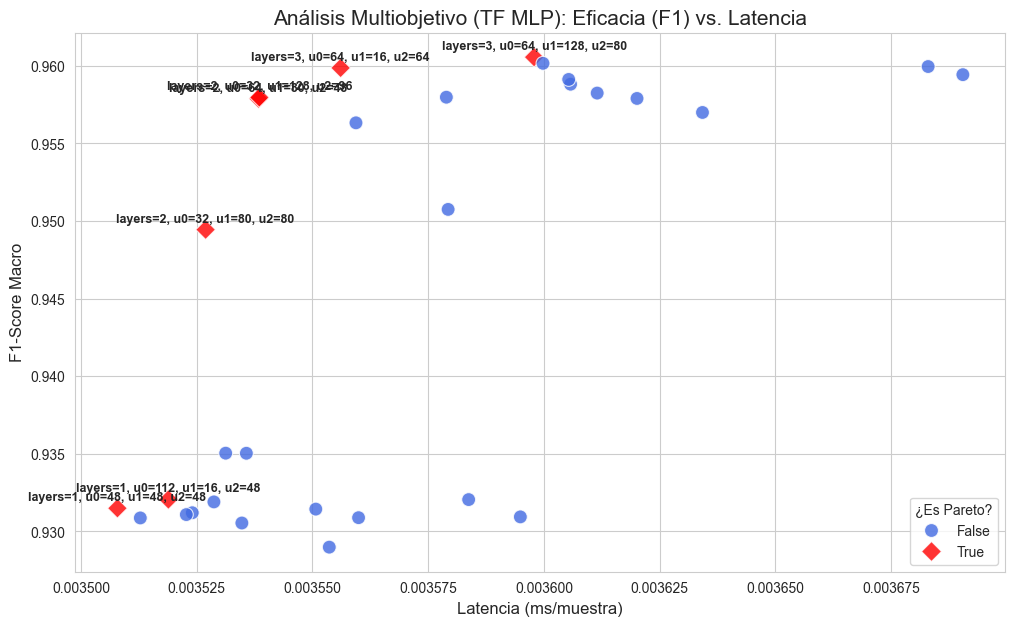

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Leer los resultados guardados del estudio del MLP TensorFlow
df = pl.read_csv("tf_mlp_ton_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"layers={int(row['n_layers'])}, u0={int(row['n_units_l0'])}, u1={int(row['n_units_l1'])}, u2={int(row['n_units_l2'])}",
        fontsize=9,
        fontweight="bold",
        ha="center"
    )

plt.title("Análisis Multiobjetivo (TF MLP): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()


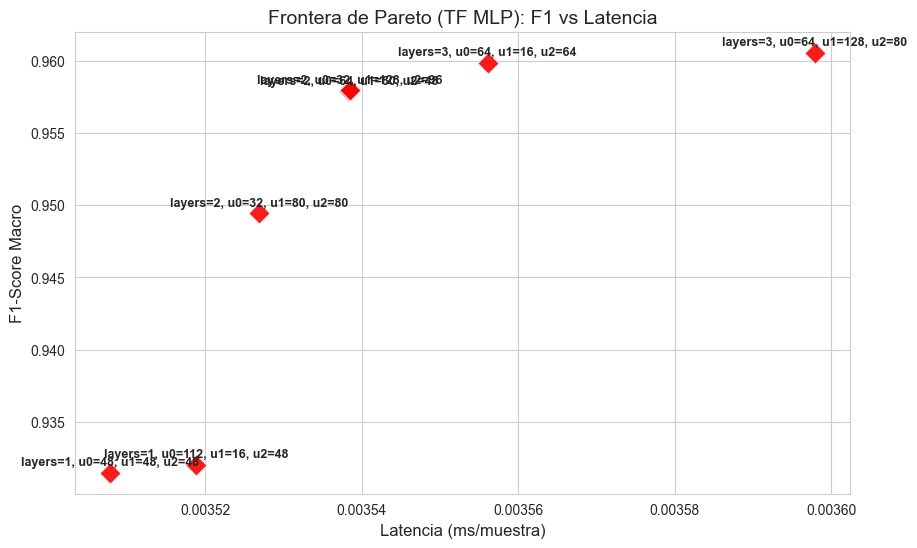

Puntos de Pareto:


n_layers,n_units_l0,n_units_l1,n_units_l2,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,i64,i64,f64,f64,f64,bool
1,48,48,48,0.931487,0.000058,0.003508,true
1,112,16,48,0.932051,0.000762,0.003519,true
2,32,80,80,0.949445,0.007818,0.003527,true
2,64,80,48,0.95788,0.000558,0.003538,true
2,32,128,96,0.957968,0.000364,0.003539,true
3,64,16,64,0.959869,0.000648,0.003556,true
3,64,128,80,0.960564,0.000077,0.003598,true


In [5]:
# SOLO REPRESENTAMOS LOS PUNTOS DE LA FRONTERA DE PARETO

pareto_df = df.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.9
)

for row in pareto_df.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"layers={int(row['n_layers'])}, u0={int(row['n_units_l0'])}, u1={int(row['n_units_l1'])}, u2={int(row['n_units_l2'])}",
        fontsize=9,
        fontweight="bold",
        ha="center"
    )

plt.title("Frontera de Pareto (TF MLP): F1 vs Latencia", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.grid(True)
plt.show()

print("Puntos de Pareto:")
display(pareto_df)

In [6]:
import os
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# BLOQUE 0: PARCHE PARA FORZAR USO DE CPU
# ==========================================
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

import tensorflow as tf
from tensorflow import keras

# ==========================================
# EVALUACIÓN FINAL EN TEST (4 CANDIDATOS MLP)
# ==========================================

candidatos = [
    {"h": (32, 80, ), "nombre": "Candidato 1"},
    {"h": (64, 80, ), "nombre": "Candidato 2"},
    {"h": (32, 128, ),   "nombre": "Candidato 3"},
    {"h": (64, 16, 64),  "nombre": "Candidato 4"},
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (TensorFlow MLP) ---\n")

# 1. Aseguramos que todo sea NumPy para evitar warnings
X_train_np = np.array(X_full_train_np)
X_test_np_arr = np.array(X_test_np)

# 2. Convertimos y_train/y_test a 0/1 para métricas binarias correctas
y_full_train01 = ((np.array(y_full_train) + 1) // 2).astype(np.int8)
y_test_np01    = ((np.array(y_test_np) + 1) // 2).astype(np.int8)

# 3. ESCALADO DE DATOS (Vital para MLP, sin Data Leakage)
print("Normalizando datos (ajustando solo en Train)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np_arr)

for c in candidatos:
    print(f"\n🚀 Probando: {c['nombre']} (Capas={len(c['h'])}, Neuronas={c['h']})...")
    
    # Limpiamos memoria RAM para que no se acumulen modelos
    tf.keras.backend.clear_session()

    # 4. Inicializamos modelo dinámico
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)))
    
    for units in c["h"]:
        model.add(keras.layers.Dense(units, activation="relu"))
        
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    
    # 5. Entrenamiento (Separamos un 10% interno para el Early Stop)
    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    
    model.fit(
        X_train_scaled, y_full_train01,
        validation_split=0.1, 
        epochs=40,
        batch_size=2048,
        callbacks=[early_stop],
        verbose=0
    )

    # 6. Medición en el Set de Test
    # Warm-up (despertar cachés del procesador)
    _ = model.predict(X_test_scaled[:min(1000, len(X_test_scaled))], verbose=0)

    # Cronometramos la predicción de todo el bloque
    t0 = time.perf_counter()
    y_pred_prob = model.predict(X_test_scaled, batch_size=4096, verbose=0)
    t1 = time.perf_counter()
    
    # Convertimos probabilidades a 0 o 1
    y_pred01 = (y_pred_prob > 0.5).astype(np.int8).flatten()

    # 7. Cálculo de métricas
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000 # ms por muestra
    
    f1_test = f1_score(y_test_np01, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_np01, y_pred01)

    # 8. Guardado de resultados
    resultados_finales.append({
        "Perfil": c["nombre"],
        "Num_Capas": len(c["h"]),
        "Estructura": str(c["h"]),
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

# 9. Creación de la tabla final
df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*85)
print("                    TABLA COMPARATIVA FINAL (TensorFlow MLP)")
print("="*85)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (TensorFlow MLP) ---

Normalizando datos (ajustando solo en Train)...

🚀 Probando: Candidato 1 (Capas=2, Neuronas=(32, 80))...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



🚀 Probando: Candidato 2 (Capas=2, Neuronas=(64, 80))...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



🚀 Probando: Candidato 3 (Capas=2, Neuronas=(32, 128))...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



🚀 Probando: Candidato 4 (Capas=3, Neuronas=(64, 16, 64))...


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



                    TABLA COMPARATIVA FINAL (TensorFlow MLP)
shape: (4, 6)
┌─────────────┬───────────┬──────────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ Num_Capas ┆ Estructura   ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---       ┆ ---          ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ i64       ┆ str          ┆ f64      ┆ f64           ┆ f64         │
╞═════════════╪═══════════╪══════════════╪══════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 2         ┆ (32, 80)     ┆ 0.961973 ┆ 0.9733        ┆ 0.002257    │
│ Candidato 2 ┆ 2         ┆ (64, 80)     ┆ 0.962048 ┆ 0.973418      ┆ 0.002328    │
│ Candidato 3 ┆ 2         ┆ (32, 128)    ┆ 0.96124  ┆ 0.972873      ┆ 0.00237     │
│ Candidato 4 ┆ 3         ┆ (64, 16, 64) ┆ 0.963034 ┆ 0.97401       ┆ 0.002268    │
└─────────────┴───────────┴──────────────┴──────────┴───────────────┴─────────────┘
